# Exploratory Data Analysis (EDA)

In [1]:
# Loading Python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from pathlib import Path

In [3]:
# Loading the application and the bureau datasets
data_dir = Path("../data")
df_app = pd.read_csv(data_dir / "application_train.csv")
df_app, _ = train_test_split(df_app, test_size=0.2, random_state=42)
print(df_app.shape)

(246008, 122)


In [4]:
df_app.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
123473,243191,0,Cash loans,F,Y,N,0,171000.0,555273.0,16366.5,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,1.0
10118,111778,0,Cash loans,M,N,Y,1,157500.0,198085.5,23638.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
64716,175057,1,Cash loans,M,Y,Y,0,135000.0,776304.0,25173.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,5.0
234940,372147,0,Cash loans,M,Y,Y,1,164133.0,900000.0,36787.5,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,3.0
236051,373412,0,Cash loans,M,N,Y,0,225000.0,533668.5,21294.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,4.0


In [5]:
df_app.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,246008.000000,246008.000000,246008.000000,2.460080e+05,2.460080e+05,245998.000000,2.457840e+05,246008.000000,246008.000000,246008.000000,...,246008.000000,246008.000000,246008.000000,246008.000000,212797.00000,212797.000000,212797.000000,212797.000000,212797.000000,212797.000000
mean,278264.807084,0.080794,0.416230,1.684589e+05,5.996413e+05,27120.236898,5.389831e+05,0.020855,-16038.934417,63852.885366,...,0.008130,0.000581,0.000496,0.000309,0.00648,0.006729,0.034211,0.266644,0.266921,1.901126
std,102833.303590,0.272519,0.720665,1.045299e+05,4.030988e+05,14510.664192,3.700527e+05,0.013818,4361.270335,141306.599308,...,0.089798,0.024103,0.022264,0.017574,0.08424,0.106693,0.204336,0.911958,0.834133,1.870273
min,100003.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189116.750000,0.000000,0.000000,1.125000e+05,2.700000e+05,16506.000000,2.385000e+05,0.010006,-19682.000000,-2758.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278336.500000,0.000000,0.000000,1.462500e+05,5.147775e+05,24903.000000,4.500000e+05,0.018850,-15755.000000,-1212.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367296.750000,0.000000,1.000000,2.025000e+05,8.086500e+05,34654.500000,6.795000e+05,0.028663,-12418.000000,-288.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.350000e+07,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,3.00000,9.000000,8.000000,27.000000,261.000000,25.000000


Observation : 
- The Target Variable distribution is 92%-8% (heavily imbalanced)
- DAYS_EMPLOYED holds a large value (sentinel) which needs to be replaced before modeling.
- AMT_INCOME_TOTAL has a median of 146,250, a 75th percentile of 202,500, but a maximum of 13,500,000 (13.5 million). Log transformation or capping/clipping is necessary for non-tree algorithms.
- CNT_CHILDREN Outlier: Maximum number of children is 19, while the 75th percentile is 1
- Features like DAYS_BIRTH (mean: -16,038 ≈ 44 years old) and DAYS_EMPLOYED are negative relative to the application date.
- Credit Bureau Requests (AMT_REQ_CREDIT_BUREAU_*): Count is 212,797 out of 246,008 (~13.5% missing). Imputation will be needed.
- Document Flags (FLAG_DOCUMENT_*): Most flags (18, 19, 20, 21) are extremely sparse, with means well below 1%, indicating very low variance.

In [6]:
df_app['AGE'] = (-df_app['DAYS_BIRTH']) / 365
df_app = df_app.drop('DAYS_BIRTH', axis=1)
# Replace the sentinel value with NaN
df_app['DAYS_EMPLOYED'] = df_app['DAYS_EMPLOYED'].replace(365243, np.nan)

In [7]:
# Shape of the DataFrame
print("Shape:", df_app.shape)

# Column names
print("\nColumn Names:")
print(df_app.columns.tolist())

# Identify numeric columns
numeric_cols = df_app.select_dtypes(include=['number']).columns.tolist()

# Identify categorical columns
categorical_cols = df_app.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

Shape: (246008, 122)

Column Names:
['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 

In [8]:
# Count and percentage of missing values for each column
missing = pd.DataFrame({
    'Missing Count': df_app.isnull().sum(),
    'Missing %': (df_app.isnull().sum() / len(df_app) * 100).round(2)
})

# Sort by missing count (highest first)
missing = missing.sort_values(by='Missing Count', ascending=False)

print(missing)

                          Missing Count  Missing %
COMMONAREA_AVG                   171929      69.89
COMMONAREA_MODE                  171929      69.89
COMMONAREA_MEDI                  171929      69.89
NONLIVINGAPARTMENTS_MEDI         170868      69.46
NONLIVINGAPARTMENTS_MODE         170868      69.46
...                                 ...        ...
FLAG_DOCUMENT_17                      0       0.00
FLAG_DOCUMENT_16                      0       0.00
FLAG_DOCUMENT_15                      0       0.00
FLAG_DOCUMENT_21                      0       0.00
AGE                                   0       0.00

[122 rows x 2 columns]


Observation
- Features related to apartment and building specs (COMMONAREA_*, NONLIVINGAPARTMENTS_*, LIVINGAPARTMENTS_*, YEARS_BUILD_*) miss nearly 70% of their data. This occurs because detailed property characteristics are only recorded for a small subset of applicants (typically real estate collateral loans).
- Features exist in triplets (_AVG, _MODE, _MEDI). Since all three columns in a set share identical missing percentages, they are collected from the exact same source.
- Fundamental flags (FLAG_DOCUMENT_*), engineered demographic features (AGE), basic loan metadata, and core IDs have zero missing values.

In [9]:
features_gt_50 = (missing['Missing %'] > 50).sum()

print(f"\nNumber of features with >50% missing values: {features_gt_50}")


Number of features with >50% missing values: 41


In [10]:
# Class distribution as percentages
target_distribution = df_app['TARGET'].value_counts(normalize=True) * 100
print(target_distribution)

TARGET
0    91.920588
1     8.079412
Name: proportion, dtype: float64


Observation
- Only 8% of the minority class is represented in this dataset.
- This constitutes a class imbalance situation.
- AUC-PR score would perhaps be the most important metric to evaluate the performance of the ML models.

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_default_rate(
    df_app, 
    column, 
    min_count=500, 
    top_n=10
):
    """
    Plot default rate by categorical column.

    Parameters:
    df       : DataFrame
    column   : categorical feature name
    min_count: minimum number of records per category
    top_n    : number of categories to display
    """

    # Calculate default rate and customer count
    summary = (
        df_app.groupby(column)['TARGET']
        .agg(
            default_rate='mean',
            customers='count'
        )
        .reset_index()
    )

    # Convert to percentage
    summary['default_rate'] = summary['default_rate'] * 100

    # Filter small categories
    summary = (
        summary[summary['customers'] >= min_count]
        .sort_values('default_rate', ascending=False)
        .head(top_n)
    )

    # Plot
    plt.figure(figsize=(10, 6))

    sns.barplot(
        data=summary,
        x='default_rate',
        y=column
    )

    plt.xlabel("Default Rate (%)")
    plt.ylabel(column)
    plt.title(f"Top {top_n} {column} Segments by Default Rate")

    plt.show()

    return summary


NAME_CONTRACT_TYPE


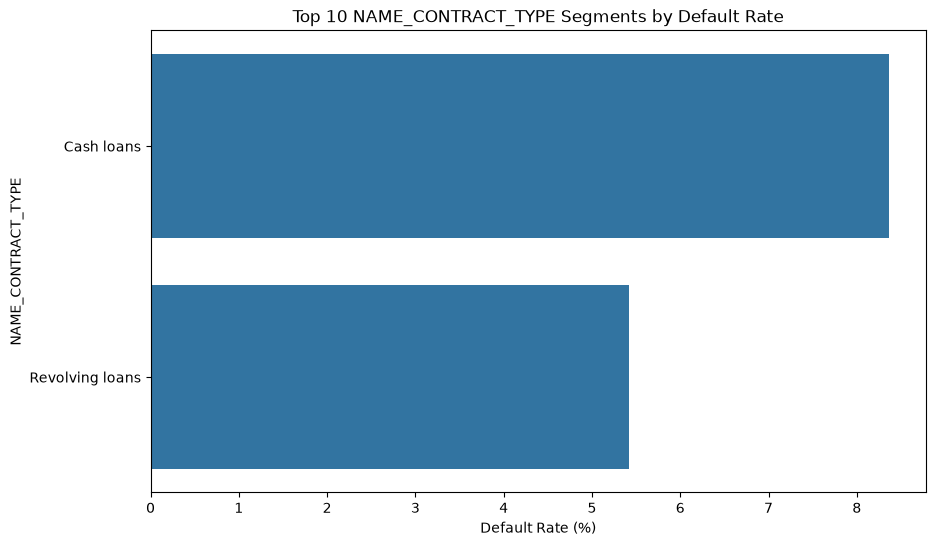

,NAME_CONTRACT_TYPE,default_rate,customers
0,Cash loans,8.360376,222490
1,Revolving loans,5.421379,23518



NAME_INCOME_TYPE


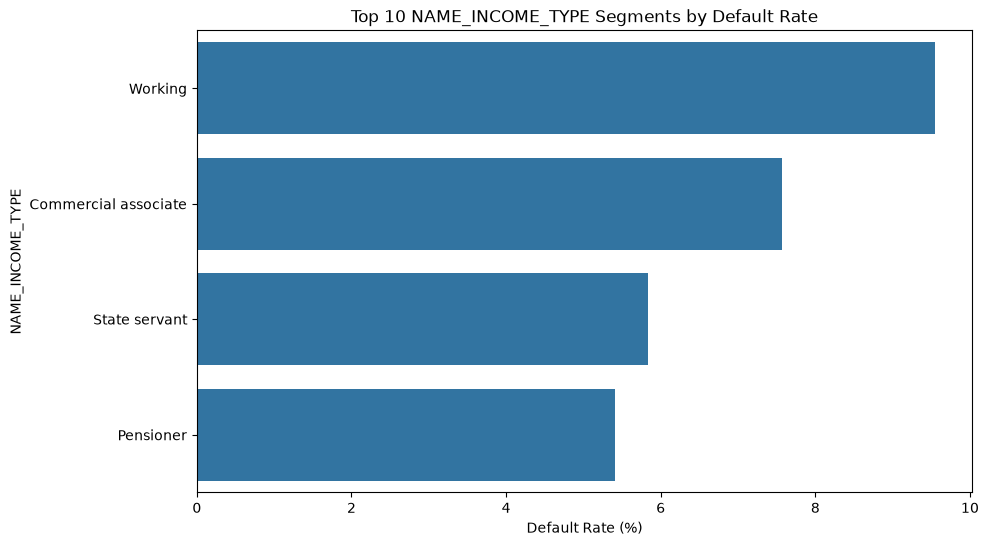

,NAME_INCOME_TYPE,default_rate,customers
7,Working,9.547070,126929
1,Commercial associate,7.567275,57339
4,State servant,5.833957,17381
3,Pensioner,5.411382,44314



OCCUPATION_TYPE


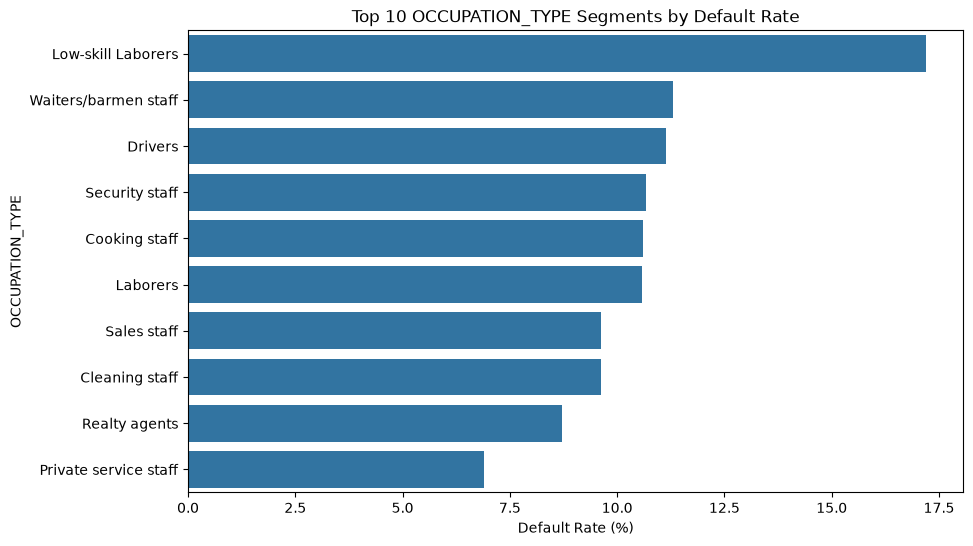

,OCCUPATION_TYPE,default_rate,customers
9,Low-skill Laborers,17.199759,1657
17,Waiters/barmen staff,11.297852,1071
4,Drivers,11.144700,14886
16,Security staff,10.679070,5375
2,Cooking staff,10.601536,4688
8,Laborers,10.572159,44201
14,Sales staff,9.620639,25622
1,Cleaning staff,9.618485,3722
13,Realty agents,8.724832,596
12,Private service staff,6.903073,2115



ORGANIZATION_TYPE


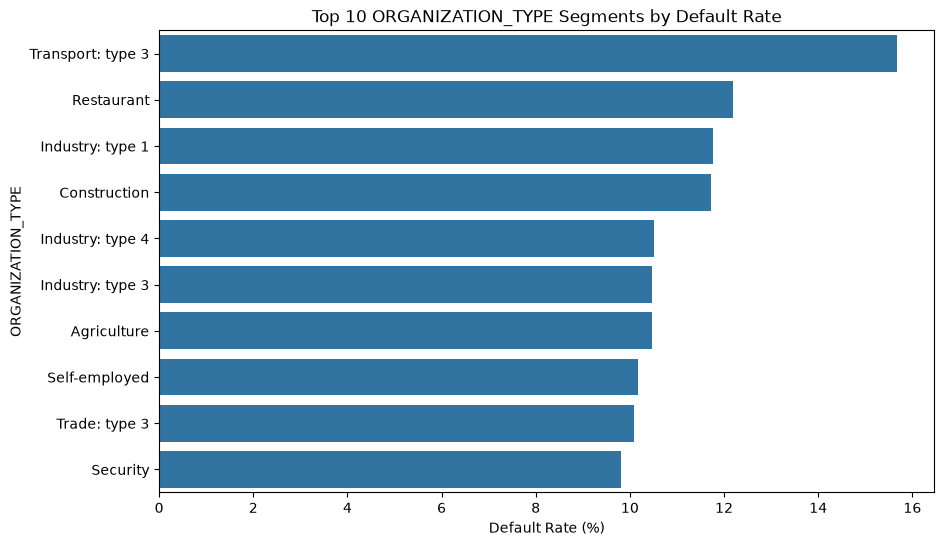

,ORGANIZATION_TYPE,default_rate,customers
54,Transport: type 3,15.677966,944
38,Restaurant,12.191781,1460
14,Industry: type 1,11.757576,825
7,Construction,11.725664,5424
21,Industry: type 4,10.504202,714
20,Industry: type 3,10.471807,2607
1,Agriculture,10.462164,1969
42,Self-employed,10.182410,30700
47,Trade: type 3,10.082526,2787
40,Security,9.813809,2578


In [12]:
categorical_features = [
    'NAME_CONTRACT_TYPE',
    'NAME_INCOME_TYPE',
    'OCCUPATION_TYPE',
    'ORGANIZATION_TYPE'
]

# Plotting the default rate bar charts for each of the categorical features

for feature in categorical_features:
    print("\n", "="*60)
    print(feature)
    
    result = plot_default_rate(
        df_app,
        feature,
        min_count=500,
        top_n=10
    )
    
    display(result)

Observation
- Across these categorical groups, loan default risk averages around 8% but varies sharply depending on employment stability and contract terms.
- Cash loans, low-skilled laborers, service workers, and construction or transport sectors carry the highest default rates (10–17%).
- Conversely, pensioners, state servants, and revolving loans show significantly safer repayment profiles (5–6%).

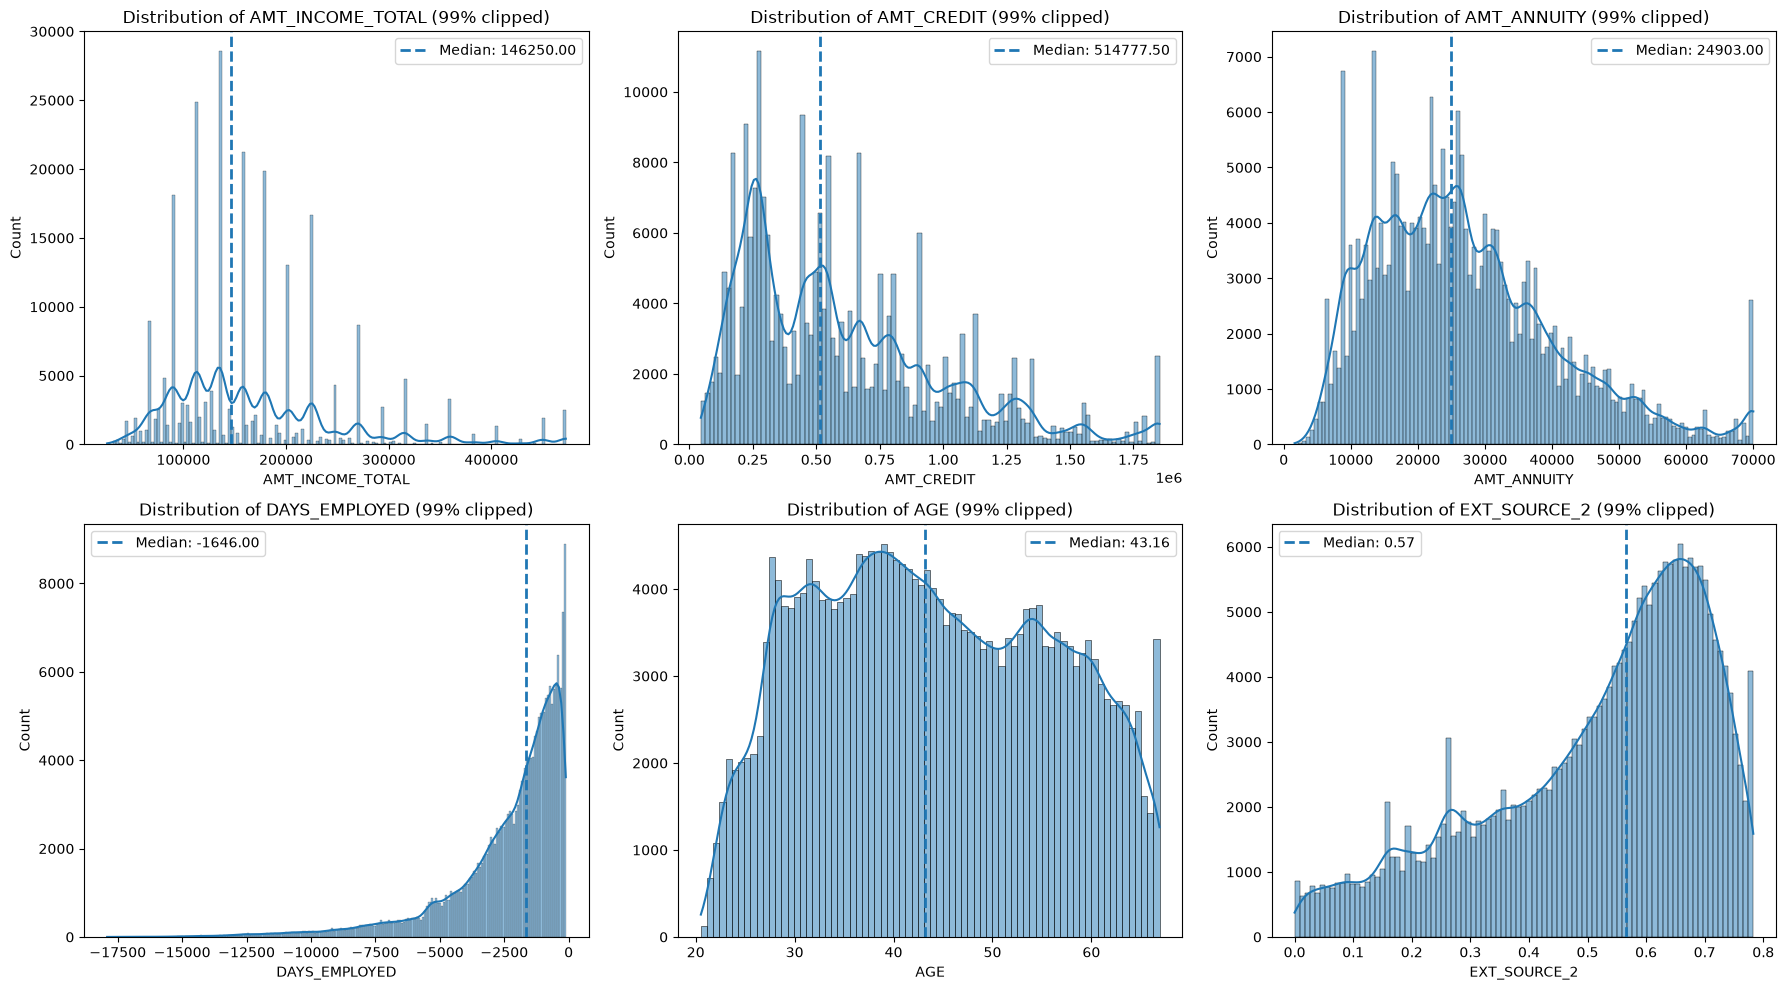

In [13]:
features = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'DAYS_EMPLOYED',
    'AGE',
    'EXT_SOURCE_2'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, features):
    
    # Remove missing values
    data = df_app[col].dropna()

    # Clip values above 99th percentile
    upper_limit = data.quantile(0.99)
    data_clipped = data.clip(upper=upper_limit)

    # Plot distribution
    sns.histplot(
        data_clipped,
        kde=True,
        ax=ax
    )

    # Median line (from clipped data)
    median = data_clipped.median()

    ax.axvline(
        median,
        linestyle='--',
        linewidth=2,
        label=f'Median: {median:.2f}'
    )

    ax.set_title(f'Distribution of {col} (99% clipped)')
    ax.set_xlabel(col)
    ax.legend()

plt.tight_layout()
plt.show()

Observation
-  AMT_INCOME_TOTAL, AMT_CREDIT & AMT_ANNUITY are all right-skewed, with the number of high-earners diminishing towards the tail end.
-  Most employees are either juniors or mid-level with the median value of DAYS_EMPLOYED being only 1646 days (~ 4.5 years) and is left-skewed.
-  The distribution for EXT_SOURCE_2, a credit score reporting agency, is surprisingly left skewed as it is expected to be a key predictor for  defaulters.

In [14]:
# Select numeric columns
numeric_df = df_app.select_dtypes(include=['number'])

# Calculate correlation with TARGET
target_corr = numeric_df.corr()['TARGET'].sort_values(ascending=False)

# Get top 15 features excluding TARGET itself
top_features = (
    target_corr
    .drop('TARGET')
    .abs()
    .sort_values(ascending=False)
    .head(15)
    .index
)

print("Top 15 features correlated with TARGET:")
print(top_features)

Top 15 features correlated with TARGET:
Index(['EXT_SOURCE_3', 'EXT_SOURCE_2', 'EXT_SOURCE_1', 'AGE', 'DAYS_EMPLOYED',
       'REGION_RATING_CLIENT_W_CITY', 'REGION_RATING_CLIENT',
       'DAYS_LAST_PHONE_CHANGE', 'DAYS_ID_PUBLISH', 'REG_CITY_NOT_WORK_CITY',
       'FLAG_EMP_PHONE', 'FLAG_DOCUMENT_3', 'REG_CITY_NOT_LIVE_CITY',
       'FLOORSMAX_AVG', 'FLOORSMAX_MEDI'],
      dtype='object')


Observation
- Expectedly, the EXT_SOURCE features are all highly correlated with the target variable, and probably feature engineering them could improve modeling
- AGE & DAYS_EMPLOYED also influence the chances of defaulting and if the applicant is "FLAGGED", it could potentially influence the final decision of the model.
- If the applicant is registered in a city where he does not live/ work, it affects his chances at defaulting.

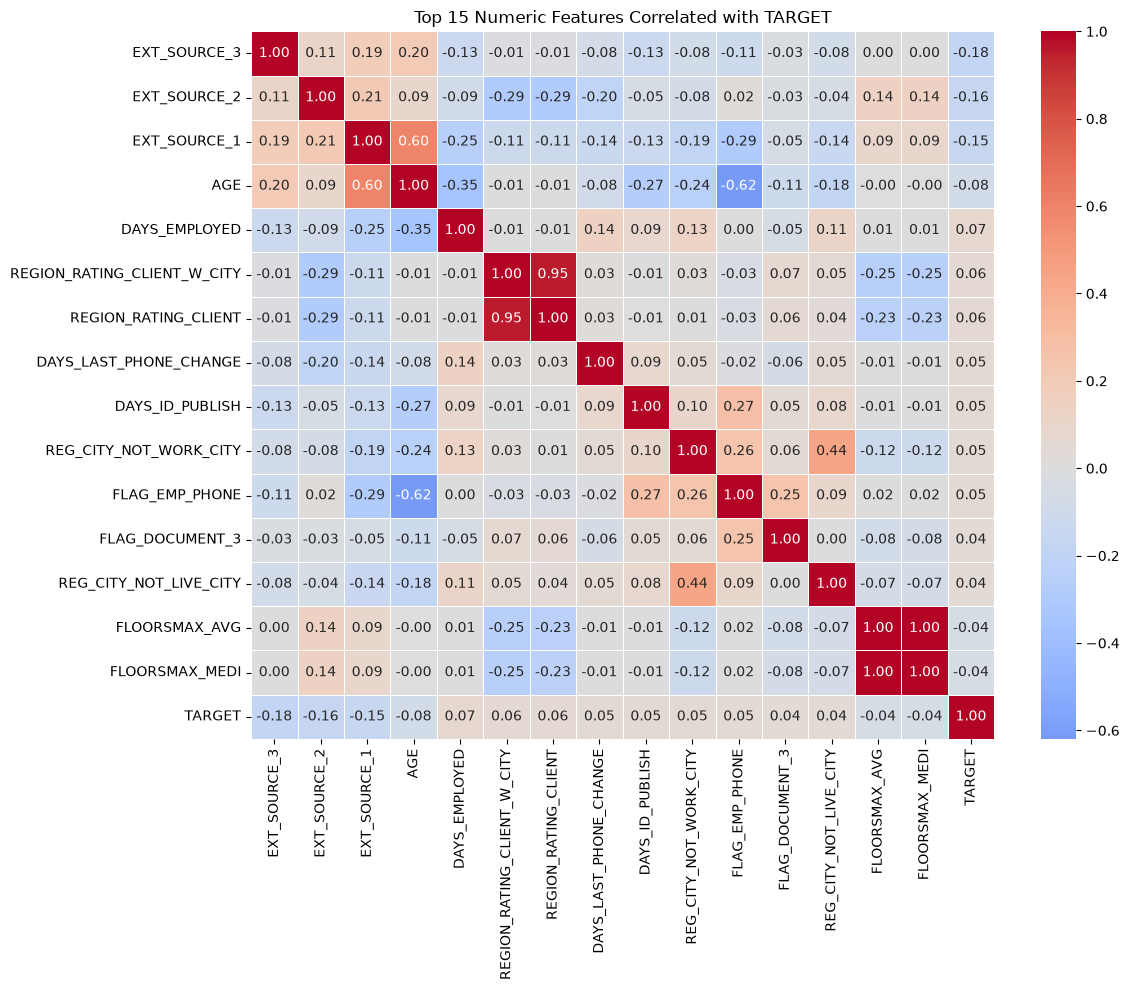

In [15]:
# Include TARGET with the selected features
heatmap_features = list(top_features) + ['TARGET']

corr_matrix = df_app[heatmap_features].corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=0.5
)

plt.title("Top 15 Numeric Features Correlated with TARGET")
plt.tight_layout()

plt.show()

Observation
- Looking at the correlation heatmap, Age & Credit Score reported from EXT_SOURCE_1 have a 0.6 score showing moderate correlation
- FLOORSMAX_AVG & FLOORSMAX_MEDI are perfectly correlated, indicating similar values. This could hold true for features having _AVG, _MEDI and _MOD where one metric might be enough.
- There seems to be a minor pattern of people not living/ working in their registered city (0.44)

In [16]:
df_bur = pd.read_csv(r"E:\Users\Gautam\Desktop\capstone\data\bureau.csv")
df_bur.head()

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [17]:
bureau_counts = (
    df_bur
    .groupby('SK_ID_CURR')
    .size()
    .reset_index(name='num_bureau_records')
)

df = df_app.merge(
    bureau_counts,
    on='SK_ID_CURR',
    how='left'
)
df['num_bureau_records'] = df['num_bureau_records'].fillna(-1).astype(int)
#bureau_counts.head()

In [18]:
bureau_default = (
    df.groupby('num_bureau_records')['TARGET']
    .agg(
        default_rate='mean',
        customers='count'
    )
    .reset_index()
)

# Convert to percentage
bureau_default['default_rate'] *= 100

# Remove very small groups
bureau_default = bureau_default[
    bureau_default['customers'] >= 100
]

#bureau_default.head()

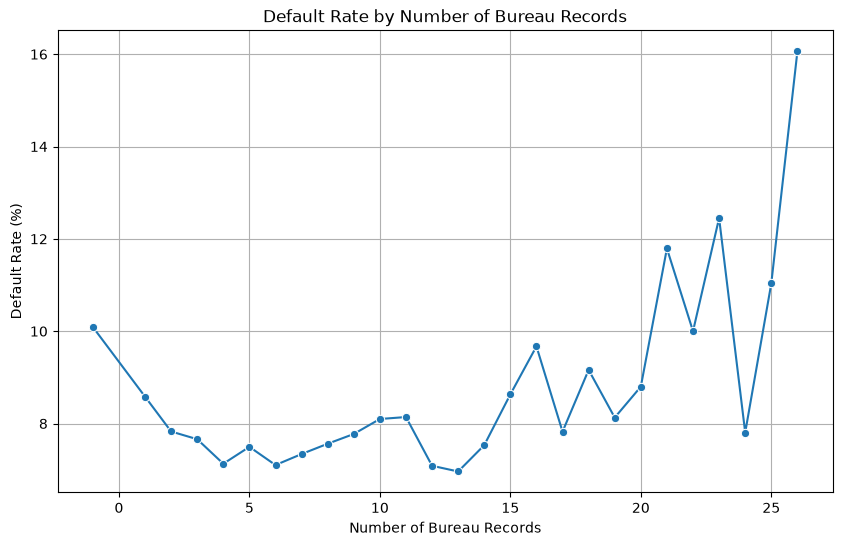

In [19]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=bureau_default,
    x='num_bureau_records',
    y='default_rate',
    marker='o'
)

plt.xlabel("Number of Bureau Records")
plt.ylabel("Default Rate (%)")
plt.title("Default Rate by Number of Bureau Records")
plt.grid(True)

plt.show()

OBSERVATION
- Ignoring the value on the far left (as this indicates the missing values), the default rate generally increases with the number of bureau records, barring fluctuations.